In [61]:
import sys
import os
import pandas as pd
import numpy as np
from pycox.models.cox import CoxPH
from pycox.evaluation import EvalSurv
import matplotlib.pyplot as plt
import torchtuples as tt
import shap
sys.path.append(os.path.abspath("../../"))
from src.dataset.generate_dataset import TorchPreprocessing
from src.dataset.DataSet import SurvivalDataSet
from src.utils.Preprocessing import Preprocessor
from src.utils.ConvertTextToCsv import TextToCsv
from src.dataset.split_data import split_data_Train_Val_Test, create_dataloaders_train_val_test
import scipy.integrate
from sklearn.preprocessing import StandardScaler
from src.utils.cox_models import *
scipy.integrate.simps = scipy.integrate.simpson
from sksurv.nonparametric import kaplan_meier_estimator
from sksurv.compare import compare_survival
from sksurv.util import Surv
from itertools import product
import torch

import random
import numpy as np
import torch


%load_ext autoreload
%autoreload 2
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [62]:
SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed()

In [63]:
pp = Preprocessor()

In [64]:
df_clinical_data = pd.read_csv("../../data/raw/brca_tcga_pub2015_clinical_data.tsv", sep='\t')
df_clinical_data = pp.clean_columns_dataset(df_clinical_data)
list_df = pp.total_type_len_type_cancer(df_clinical_data)
df_clinical_data["Tumor-Cancer"] = list_df
df_clinical_data["Tumor-Cancer"].unique()

df_mRNA_raw_data = TextToCsv("../../data/raw/data_mrna_seq_v2_rsem.txt")


Luminal A: 330 - Total(%): 0.40
Luminal B: 81 - Total(%):0.10
HER2-enriched: 23 - Total(%):0.03
TNBC: 85 - Total(%)0.10 
UNK: 298 - Total(%) 0.36
Shape of the CSV: (20440, 819)


In [65]:
df_merged = TorchPreprocessing(df_mRNA_raw_data,df_clinical_data, 23360).get_comparation_df()
 
comparation_df = df_merged.loc[
    df_merged["Tumor-Cancer"].isin(["Luminal A", "Luminal B", "TNBC", "HER2-enriched"]),
]

comparation_df["Tumor-Cancer"].unique()

print(f"Samples: {comparation_df.shape[0]}, Genes: {comparation_df.shape[1]}")

Genes before Treshold: 20434
count    20434.000000
mean        73.977831
std        155.539160
min          0.000000
25%          0.000000
50%          0.000000
75%         21.000000
max        519.000000
dtype: float64
Threshold (>80% zeros): 415 samples
After the treshold: 18533
Samples: 519, Genes: 18534


In [67]:
zero_reduced_df =  comparation_df.drop(["Sample ID"], axis=1)
results_df, desing, expr = pp.initialize_limma(zero_reduced_df, column="Tumor-Cancer", column_event="Overall Survival (Months)", column_status="Overall Survival Status")

In [68]:
results_df

,HER2-enriched,Luminal A,Luminal B,TNBC,AveExpr,F,pvalue,adj_pvalue
YTHDF1,10.879097,10.704586,10.782180,10.716942,10.726453,69230.027576,0.000000e+00,0.000000e+00
STRADA,9.487686,9.188342,9.375162,8.935217,9.189309,40043.610021,0.000000e+00,0.000000e+00
PIK3R6,4.953432,5.001262,5.058186,5.178365,5.037032,4016.626570,0.000000e+00,0.000000e+00
SAMD9,9.454183,9.385430,9.352988,9.353712,9.378219,8472.898002,0.000000e+00,0.000000e+00
YME1L1,12.087980,11.915021,11.968255,12.079383,11.957913,100013.934220,0.000000e+00,0.000000e+00
...,...,...,...,...,...,...,...,...
TMEM229A,0.349584,0.207897,0.218256,0.103054,0.198622,12.900652,1.670292e-10,1.670652e-10
PAGE2,0.285851,0.312058,0.459990,0.754457,0.406439,12.836736,1.889000e-10,1.889306e-10
SLC28A2,0.355432,0.277010,0.242954,0.086340,0.243943,12.577395,3.111464e-10,3.111800e-10
FMR1NB,0.084961,0.267415,0.215001,0.499620,0.289179,11.949205,1.040456e-09,1.040512e-09


In [69]:
N_GENES = 1000
top_genes_limma = results_df.sort_values("pvalue").index[:N_GENES].tolist()

In [70]:
torch_preprocessing = TorchPreprocessing(df_mRNA_raw_data, df_clinical_data, 23360)
torch_preprocessing.genes_expression = top_genes_limma
genes_expression = top_genes_limma
X_scaled, durations, events, scaler = torch_preprocessing.get_data_set(60)



Genes before Treshold: 1003
count    1003.000000
mean        1.442672
std         5.964587
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        94.000000
dtype: float64
Threshold (>80% zeros): 415 samples
After the treshold: 1003


In [71]:
X_scaled.shape

(519, 1000)

In [72]:
surival_data_set  = SurvivalDataSet(X_scaled, durations, events)

In [128]:
set_seed()
(train_X, train_durations, train_events), \
(val_X, val_durations, val_events), \
(test_X, test_durations, test_events) = split_data_Train_Val_Test(surival_data_set)
print(f"Train: {train_X.shape[0]}, Val: {val_X.shape[0]}, Test: {test_X.shape[0]}")

Train: 415, Val: 52, Test: 52


In [38]:
train_X.shape

torch.Size([415, 1000])

Grid Search for the best Model

In [74]:
from itertools import product

in_features = train_X.shape[1]
output_bias = False
param_grid = {
    "num_nodes": [
        [16], [32], [64], [128],
        [16, 16], [32, 16], [32, 32],
    ],
    "dropout": [0.2, 0.4],
    "batch_norm": [True, False],
    "lr": [1e-3, 5e-4, 1e-4],
    "weight_decay": [0, 1e-4, 1e-3],
    "batch_size": [128, 256],
}
grid = list(product(
    param_grid["num_nodes"],
    param_grid["dropout"],
    param_grid["batch_norm"],
    param_grid["lr"],
    param_grid["weight_decay"],
    param_grid["batch_size"],
))

In [75]:
from pycox.evaluation import EvalSurv

best_score = -1
best_params = None
grid_results = []

set_seed()
val_X = np.array(val_X)
val_durations = np.array(val_durations)
val_events = np.array(val_events).astype(bool)

for num_nodes, dp, bn, lr, wd, batch_size in grid:
    try:
        net = tt.torchtuples.practical.MLPVanilla(
            in_features=in_features,
            num_nodes=num_nodes,
            out_features=1,
            dropout=dp,
            output_bias=False,
            batch_norm=bn,
        )
        model_gs = CoxPH(net, tt.torchtuples.optim.Adam(lr=lr, weight_decay=wd))
        
        callbacks = [tt.torchtuples.callbacks.EarlyStopping(patience=20)]
        model_gs.fit(
            input=train_X,
            target=(train_durations, train_events),
            batch_size=batch_size,
            epochs=100,
            callbacks=callbacks,
            verbose=False,
            val_data=(val_X, (val_durations, val_events)),
            val_batch_size=batch_size
        )
        
        
        model_gs.compute_baseline_hazards()
        surv_val = model_gs.predict_surv_df(val_X)
        ev = EvalSurv(surv_val, val_durations, val_events, censor_surv='km')
        c_index = ev.concordance_td()

        grid_results.append({
            'num_nodes': num_nodes, 'dropout': dp, 'batch_norm': bn,
            'lr': lr, 'weight_decay': wd, 'batch_size': batch_size,
            'c_index': c_index
        })

        if c_index > best_score:
            best_score = c_index
            best_params = {
                'num_nodes': num_nodes, 'dropout': dp, 'batch_norm': bn,
                'lr': lr, 'weight_decay': wd, 'batch_size': batch_size
            }
    except Exception as e:
        continue

print(f"Mejor C-index en validación: {best_score:.4f}")
print(f"Mejores parámetros: {best_params}")

Mejor C-index en validación: 0.9737
Mejores parámetros: {'num_nodes': [64], 'dropout': 0.2, 'batch_norm': True, 'lr': 0.0005, 'weight_decay': 0, 'batch_size': 128}


Training the Model

In [76]:

out_features = 1
num_nodes    = best_params['num_nodes']
dropout      = best_params['dropout']
batch_norm   = best_params['batch_norm']
lr           = best_params['lr']
weight_decay = best_params['weight_decay']
batch_size   = best_params['batch_size']


net = tt.torchtuples.practical.MLPVanilla(
    in_features=in_features, 
    num_nodes=num_nodes, 
    out_features=out_features, 
    batch_norm=batch_norm,
    dropout=dropout,
    output_bias=output_bias
)
model = CoxPH(net, tt.torchtuples.optim.Adam(weight_decay=weight_decay))


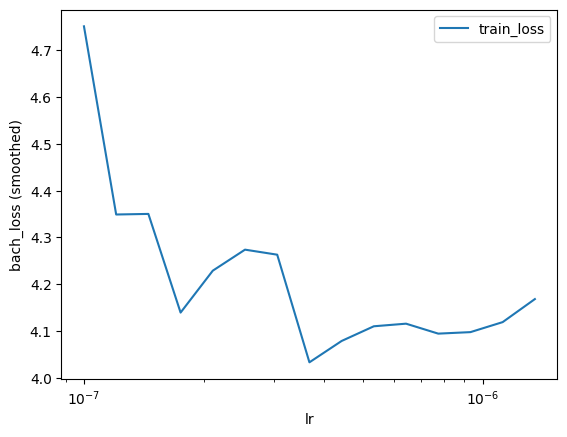

In [77]:
batch_size = batch_size
lrfinder = model.lr_finder(input=train_X,
                           target=(train_durations, train_events),
                           batch_size=batch_size,
                           tolerance=20)

_ = lrfinder.plot()

In [78]:
train_durations.shape

torch.Size([415])

In [79]:
model.optimizer.set_lr(lr)


In [80]:
epochs = 500
callbacks = [tt.torchtuples.callbacks.EarlyStopping(patience=25)]
verbose = True

In [81]:
%%time

set_seed()
torch.manual_seed(SEED)
np.random.seed(SEED)
log = model.fit(input=train_X, target=(train_durations, train_events), epochs=epochs, callbacks=callbacks, verbose=verbose, 
                val_data=(val_X,( val_durations, val_events)), val_batch_size=batch_size)

0:	[0s / 0s],		train_loss: 4.8551,	val_loss: 3.0264
1:	[0s / 0s],		train_loss: 4.4533,	val_loss: 2.9989
2:	[0s / 0s],		train_loss: 4.0567,	val_loss: 2.9600
3:	[0s / 0s],		train_loss: 3.9452,	val_loss: 2.9117
4:	[0s / 0s],		train_loss: 3.6816,	val_loss: 2.8852
5:	[0s / 0s],		train_loss: 3.5267,	val_loss: 2.8569
6:	[0s / 0s],		train_loss: 3.3605,	val_loss: 2.8392
7:	[0s / 0s],		train_loss: 3.1056,	val_loss: 2.8496
8:	[0s / 0s],		train_loss: 3.0196,	val_loss: 2.8639
9:	[0s / 0s],		train_loss: 2.9870,	val_loss: 2.8912
10:	[0s / 0s],		train_loss: 2.7955,	val_loss: 2.9313
11:	[0s / 0s],		train_loss: 2.7003,	val_loss: 2.9747
12:	[0s / 0s],		train_loss: 2.5590,	val_loss: 2.9993
13:	[0s / 0s],		train_loss: 2.5718,	val_loss: 3.0036
14:	[0s / 0s],		train_loss: 2.4528,	val_loss: 2.9956
15:	[0s / 0s],		train_loss: 2.1607,	val_loss: 2.9873
16:	[4s / 5s],		train_loss: 2.0919,	val_loss: 2.9842
17:	[0s / 5s],		train_loss: 2.1153,	val_loss: 2.9897
18:	[0s / 5s],		train_loss: 1.8928,	val_loss: 2.9982
19:

(52, 1000)

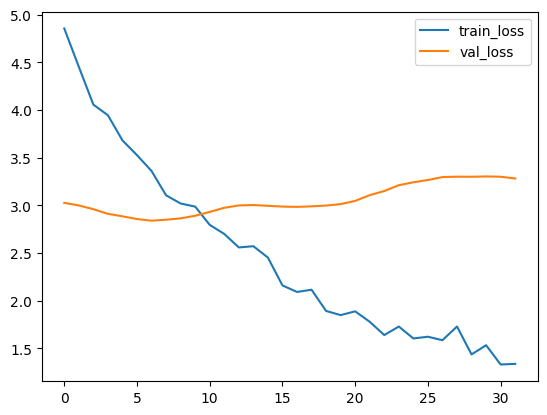

In [82]:
_ = log.plot()
val_X.shape

KapplanMeir Train

In [83]:
risk_nn_train = model.net(train_X).flatten()

list_risk_train = []
for i in risk_nn_train:
    list_risk_train.append(i.item())


For this group the risk High

For the time 0 the risk group is 201
For the time 12 the risk group is 170
For the time 24 the risk group is 101
For the time 36 the risk group is 65
For the time 48 the risk group is 41
For the time 60 the risk group is 0

For this group the risk Low

For the time 0 the risk group is 205
For the time 12 the risk group is 186
For the time 24 the risk group is 114
For the time 36 the risk group is 89
For the time 48 the risk group is 72
For the time 60 the risk group is 0


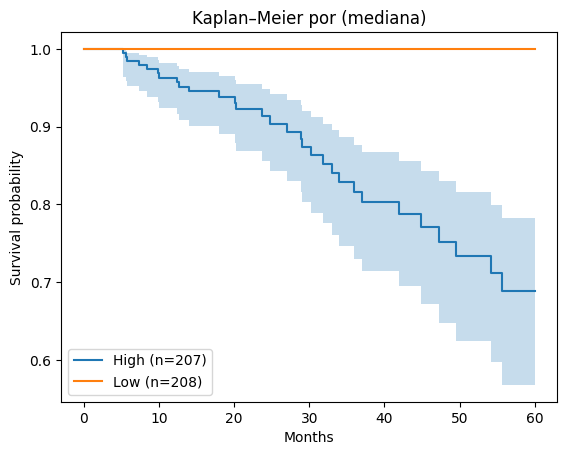

In [84]:
df = pd.DataFrame()

thr = np.median(list_risk_train)
df["group"] = np.where(risk_nn_train > thr, "High", "Low")
df["duration"] = train_durations
df["event"] = train_events

for g in ["High", "Low"]:
        sub = df[df["group"] == g]
        event = sub["event"].to_numpy(dtype=bool)
        time = sub["duration"].to_numpy(dtype=float)
            
        time_points_months = np.array([0, 12, 24, 36, 48, 60])
        at_risk = [(time > tp).sum() for tp in time_points_months]
        print(f"\nFor this group the risk {g}\n")
        x = [(time, risk) for time,risk in zip(time_points_months, at_risk)]
        for i, _ in enumerate(x):
            print(f"For the time {x[i][0]} the risk group is {x[i][1]}")
                
        event_60_month = event.copy()
        event_60_month[time > 120] = False
        time_60_months = np.minimum(time, 120)
        time, prob_survival, conf_int = kaplan_meier_estimator(event_60_month, time_60_months, conf_type="log-log")  # type: ignore # event True=evento, False=censura
        plt.step(time, prob_survival, where="post", label=f"{g} (n={len(sub)})")
        plt.fill_between(time, conf_int[0], conf_int[1], alpha=0.25, step="post")
plt.xlabel("Months")
plt.ylabel("Survival probability")
plt.title(f"Kaplan–Meier por (mediana)")
plt.legend()
plt.show()

In [85]:
time_all = df["duration"].to_numpy(dtype=float)
event_all = df["event"].to_numpy(dtype=bool)
event_60_months = event_all.copy()
event_60_months[time_all > 60] = False
time_60_months = np.minimum(time_all, 60)

y = Surv.from_arrays(event_60_months, time_60_months)
chisq, pvalue = compare_survival(y, df["group"].to_numpy())
print(f"Log-rank: chi2={chisq:.3f}, p={pvalue:.4g}")


Log-rank: chi2=37.286, p=1.02e-09


Log Likehood (The Loss)

In [86]:
model.partial_log_likelihood(*(val_X, (val_durations, val_events))).mean()


-2.8389049

In [87]:
_ = model.compute_baseline_hazards()

In [88]:
surv = model.predict_surv_df(input=test_X)

In [89]:
chf = model.predict_cumulative_hazards(test_X)
chf.shape
#275 → número de puntos de tiempo
#52 -> pacientes 

(275, 52)

Kaplan Meier

In [90]:

risk_nn_test = model.net(test_X).flatten()

list_risk_test = []
for i in risk_nn_test:
    list_risk_test.append(i.item())



For this group the risk High

For the time 0 the risk group is 26
For the time 12 the risk group is 19
For the time 24 the risk group is 9
For the time 36 the risk group is 6
For the time 48 the risk group is 4
For the time 60 the risk group is 0

For this group the risk Low

For the time 0 the risk group is 26
For the time 12 the risk group is 22
For the time 24 the risk group is 16
For the time 36 the risk group is 9
For the time 48 the risk group is 5
For the time 60 the risk group is 0


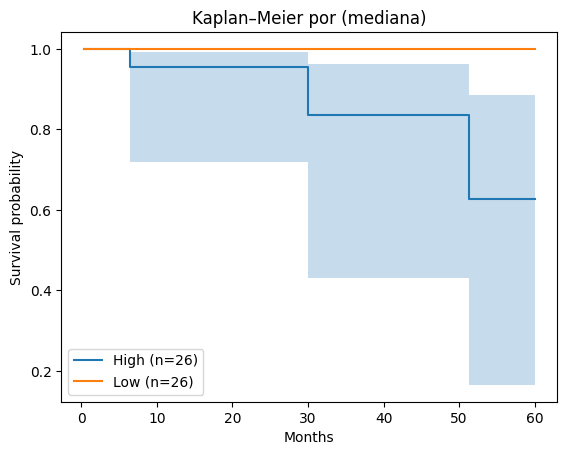

In [91]:
df = pd.DataFrame()

thr = np.median(list_risk_test)
df["group"] = np.where(risk_nn_test > thr, "High", "Low")
df["duration"] = test_durations
df["event"] = test_events

for g in ["High", "Low"]:
        sub = df[df["group"] == g]
        event = sub["event"].to_numpy(dtype=bool)
        time = sub["duration"].to_numpy(dtype=float)
            
        time_points_months = np.array([0, 12, 24, 36, 48, 60])
        at_risk = [(time > tp).sum() for tp in time_points_months]
        print(f"\nFor this group the risk {g}\n")
        x = [(time, risk) for time,risk in zip(time_points_months, at_risk)]
        for i, _ in enumerate(x):
            print(f"For the time {x[i][0]} the risk group is {x[i][1]}")
                
        event_60_month = event.copy()
        event_60_month[time > 120] = False
        time_60_months = np.minimum(time, 120)
        time, prob_survival, conf_int = kaplan_meier_estimator(event_60_month, time_60_months, conf_type="log-log")  # type: ignore # event True=evento, False=censura
        plt.step(time, prob_survival, where="post", label=f"{g} (n={len(sub)})")
        plt.fill_between(time, conf_int[0], conf_int[1], alpha=0.25, step="post")
plt.xlabel("Months")
plt.ylabel("Survival probability")
plt.title(f"Kaplan–Meier por (mediana)")
plt.legend()
plt.show()

Log Rank of the Model

In [92]:

time_all = df["duration"].to_numpy(dtype=float)
event_all = df["event"].to_numpy(dtype=bool)
event_60_months = event_all.copy()
event_60_months[time_all > 60] = False
time_60_months = np.minimum(time_all, 60)

y = Surv.from_arrays(event_60_months, time_60_months)
chisq, pvalue = compare_survival(y, df["group"].to_numpy())
print(f"Log-rank: chi2={chisq:.3f}, p={pvalue:.4g}")


Log-rank: chi2=3.512, p=0.06094


Prediction of survival of the Patients

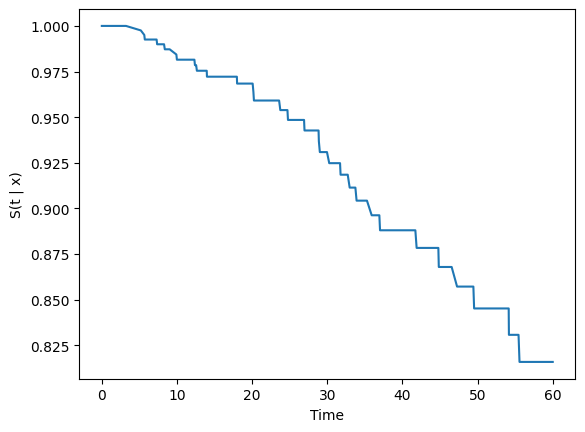

In [93]:
surv.mean(axis=1).plot()
plt.ylabel('S(t | x)')
plt.legend().set_visible(False)
_ = plt.xlabel("Time")

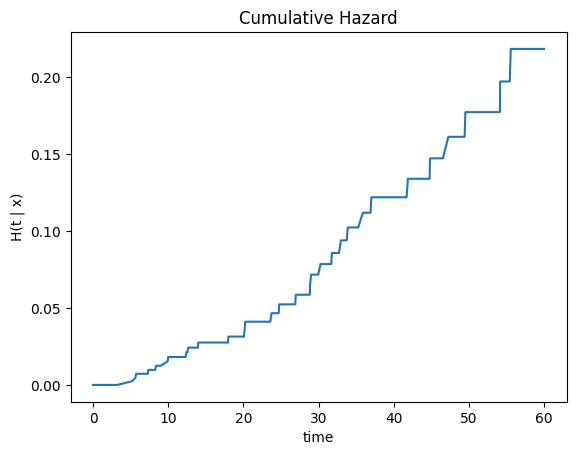

In [94]:
cum_haz = model.predict_cumulative_hazards(test_X)
cuz_model_mean = cum_haz.mean(axis=1)
cuz_model_mean.plot()
plt.xlabel("time")
plt.title("Cumulative Hazard")
plt.ylabel("H(t | x)")
plt.legend().set_visible(False)

In [95]:
test_X = np.array(test_X).astype('float32')
test_durations = np.array(test_durations).flatten()
test_events = np.array(test_events).astype(bool).flatten()

print(f"test_X shape: {test_X.shape}")
print(f"test_durations shape: {test_durations.shape}")
print(f"test_events shape: {test_events.shape}")

test_X shape: (52, 1000)
test_durations shape: (52,)
test_events shape: (52,)


In [96]:
torch.manual_seed(SEED)
np.random.seed(SEED)
ev = EvalSurv(surv=surv,
              durations=test_durations,
              events=test_events,
              censor_surv="km")


Concordance of the Model

In [97]:

print(f"Concordance of the model {ev.concordance_td()}")

Concordance of the model 0.8888888888888888


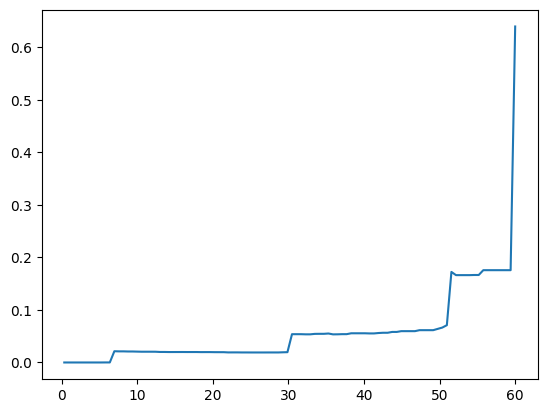

In [98]:
time_grid = np.linspace(test_durations.min(), test_durations.max(), 100)
_ = ev.brier_score(time_grid).plot()

In [99]:
ev.integrated_brier_score(time_grid=time_grid)

0.05531768983151432

In [100]:
ev.integrated_nbll(time_grid)
ci_test_deepsurv = ev.concordance_td()
ibs_deepsurv     = ev.integrated_brier_score(time_grid)

In [103]:
param_grid_cn = {
    "num_nodes":    [[16], [32], [64], [128], [256]],  
    "dropout":      [0.2, 0.4],
    "batch_norm":   [True, False],
    "lr":           [1e-3, 5e-4, 1e-4],
    "weight_decay": [0, 1e-4, 1e-3],
    "batch_size":   [128, 256],
}
grid_cn = list(product(
    param_grid_cn["num_nodes"],
    param_grid_cn["dropout"],
    param_grid_cn["batch_norm"],
    param_grid_cn["lr"],
    param_grid_cn["weight_decay"],
    param_grid_cn["batch_size"],
))

best_score_cn  = -1
best_params_cn = None
grid_results_cn = []
set_seed()
for num_nodes, dp, bn, lr, wd, batch_size in grid_cn:
    try:
        net_cn = tt.torchtuples.practical.MLPVanilla(
            in_features  = in_features,
            num_nodes    = num_nodes,       # lista de 1 elemento
            out_features = 1,
            dropout      = dp,
            output_bias  = False,
            batch_norm   = bn,
        )
        model_cn_gs = CoxPH(net_cn, tt.torchtuples.optim.Adam(lr=lr, weight_decay=wd))

        callbacks = [tt.torchtuples.callbacks.EarlyStopping(patience=5)]
        model_cn_gs.fit(
            input      = train_X,
            target     = (train_durations, train_events),
            batch_size = batch_size,
            epochs     = 100,
            callbacks  = callbacks,
            verbose    = False,
            val_data   = (val_X, (val_durations, val_events)),
            val_batch_size = batch_size,
        )

        model_cn_gs.compute_baseline_hazards()
        surv_val_cn = model_cn_gs.predict_surv_df(val_X)
        ev_cn_gs    = EvalSurv(surv_val_cn, val_durations, val_events, censor_surv='km')
        c_index_cn  = ev_cn_gs.concordance_td()

        grid_results_cn.append({
            'num_nodes': num_nodes, 'dropout': dp, 'batch_norm': bn,
            'lr': lr, 'weight_decay': wd, 'batch_size': batch_size,
            'c_index': c_index_cn
        })

        if c_index_cn > best_score_cn:
            best_score_cn  = c_index_cn
            best_params_cn = {
                'num_nodes': num_nodes, 'dropout': dp, 'batch_norm': bn,
                'lr': lr, 'weight_decay': wd, 'batch_size': batch_size
            }
    except Exception as e:
        continue

print(f"Mejor C-index en validación (Cox-nnet): {best_score_cn:.4f}")
print(f"Mejores parámetros: {best_params_cn}")

Mejor C-index en validación (Cox-nnet): 0.9737
Mejores parámetros: {'num_nodes': [256], 'dropout': 0.4, 'batch_norm': False, 'lr': 0.0005, 'weight_decay': 0, 'batch_size': 256}


In [106]:
set_seed()
torch.manual_seed(SEED)
np.random.seed(SEED)
net_cn = tt.torchtuples.practical.MLPVanilla(
    in_features=in_features, num_nodes=best_params_cn['num_nodes'],
    out_features=1, batch_norm=best_params_cn['batch_norm'],
    dropout=best_params_cn['dropout'], output_bias=False,
)
model_cn = CoxPH(net_cn, tt.torchtuples.optim.Adam(
    lr=best_params_cn['lr'], weight_decay=best_params_cn['weight_decay']
))
model_cn.fit(
    input=train_X, target=(train_durations, train_events),
    batch_size=best_params_cn['batch_size'], epochs=200, verbose=True,
    callbacks=[tt.torchtuples.callbacks.EarlyStopping(patience=15)],
    val_data=(val_X, (val_durations, val_events)),
)

model_cn.compute_baseline_hazards()
surv_cn = model_cn.predict_surv_df(test_X)
ev_cn   = EvalSurv(surv_cn, test_durations, test_events, censor_surv='km')

ci_test_coxnnet = ev_cn.concordance_td()


0:	[0s / 0s],		train_loss: 4.8768,	val_loss: 3.0896
1:	[0s / 0s],		train_loss: 4.1190,	val_loss: 3.0963
2:	[0s / 0s],		train_loss: 3.8759,	val_loss: 3.0976
3:	[0s / 0s],		train_loss: 4.0216,	val_loss: 3.0140
4:	[0s / 0s],		train_loss: 3.5423,	val_loss: 2.9320
5:	[0s / 0s],		train_loss: 3.2963,	val_loss: 2.8839
6:	[0s / 0s],		train_loss: 2.8498,	val_loss: 2.8702
7:	[0s / 0s],		train_loss: 3.1319,	val_loss: 2.8682
8:	[0s / 0s],		train_loss: 2.8136,	val_loss: 2.8912
9:	[0s / 0s],		train_loss: 2.5079,	val_loss: 2.9390
10:	[0s / 0s],		train_loss: 2.5600,	val_loss: 3.0135
11:	[0s / 0s],		train_loss: 2.4895,	val_loss: 3.0901
12:	[0s / 0s],		train_loss: 2.3057,	val_loss: 3.1526
13:	[0s / 0s],		train_loss: 2.1004,	val_loss: 3.1834
14:	[0s / 0s],		train_loss: 2.0729,	val_loss: 3.1649
15:	[0s / 0s],		train_loss: 1.9174,	val_loss: 3.1208
16:	[0s / 0s],		train_loss: 1.9127,	val_loss: 3.0822
17:	[0s / 0s],		train_loss: 1.8397,	val_loss: 3.0623
18:	[0s / 0s],		train_loss: 1.9651,	val_loss: 3.1266
19:

In [107]:
print(f"\nC-index test  DeepSurv : {ev.concordance_td():.4f}  capas: {best_params['num_nodes']}")
print(f"C-index test  Cox-nnet : {ci_test_coxnnet:.4f}  capas: {best_params_cn['num_nodes']}")


C-index test  DeepSurv : 0.8889  capas: [64]
C-index test  Cox-nnet : 0.7500  capas: [256]


In [151]:
train_X_np = train_X.cpu().numpy()
test_X_np = test_X.cpu().numpy()
train_durations_np = train_durations.cpu().numpy()
train_events_np = train_events.cpu().numpy()


train_X_np.shape, train_durations_np.shape, train_events_np.shape

((415, 1000), (415,), (415,))

In [ ]:
from sklearn.utils import resample


set_seed()
N_BOOTSTRAP = 10
gene_shap_records = {gene: [] for gene in genes_expression}

event_idx    = np.where(train_events_np == 1)[0]
no_event_idx = np.where(train_events_np == 0)[0]

for i in range(N_BOOTSTRAP):
    idx_ev = resample(event_idx,    random_state=i, replace=True)
    idx_no = resample(no_event_idx, random_state=i, replace=True)
    idx    = np.concatenate([idx_ev, idx_no])

    X_boot   = train_X_np[idx]
    dur_boot = train_durations_np[idx]
    ev_boot  = train_events_np[idx]

    ev_boot_idx    = np.where(ev_boot == 1)[0]
    no_ev_boot_idx = np.where(ev_boot == 0)[0]
    
    val_ev = resample(ev_boot_idx,    n_samples=max(3, int(0.15*len(ev_boot_idx))),    random_state=i, replace=False)
    val_no = resample(no_ev_boot_idx, n_samples=max(5, int(0.15*len(no_ev_boot_idx))), random_state=i, replace=False)
    val_idx = np.concatenate([val_ev, val_no])
    train_idx = np.setdiff1d(np.arange(len(X_boot)), val_idx)

    X_tr, X_val       = X_boot[train_idx],   X_boot[val_idx]
    dur_tr, dur_val   = dur_boot[train_idx],  dur_boot[val_idx]
    ev_tr,  ev_val    = ev_boot[train_idx],   ev_boot[val_idx]

    net_boot = tt.practical.MLPVanilla(
        in_features=in_features,
        num_nodes=best_params['num_nodes'],
        out_features=1,
        batch_norm=best_params['batch_norm'],
        dropout=best_params['dropout'],
        output_bias=False
    )

    model_boot = CoxPH(
        net_boot,
        tt.optim.Adam(lr=best_params['lr'], weight_decay=best_params['weight_decay'])
    )

    model_boot.fit(
        X_tr, (dur_tr, ev_tr),
        batch_size=best_params['batch_size'],
        epochs=200,
        verbose=False,
        callbacks=[tt.callbacks.EarlyStopping(patience=10)],
        val_data=(X_val, (dur_val, ev_val)),
    )

    def predict_fn(x):
        x_tensor = torch.tensor(x, dtype=torch.float32)
        with torch.no_grad():
            out = model_boot.net(x_tensor)
        return out.cpu().numpy().reshape(-1)

    preds_check = predict_fn(X_boot[:5])
    if np.isnan(preds_check).any():
        print(f"  → Bootstrap {i+1} divergió, saltando")
        continue

    background   = shap.sample(X_boot, 50)
    explainer    = shap.explainers.Permutation(
        predict_fn, background,
        feature_names=genes_expression,
        max_evals=2001
    )
    shap_values  = explainer(test_X_np)
    mean_abs     = np.abs(shap_values.values).mean(axis=0)

    for j, gene in enumerate(genes_expression):
        gene_shap_records[gene].append(mean_abs[j])

    print(f"Bootstrap {i+1}/{N_BOOTSTRAP} OK")

PermutationExplainer explainer:  12%|█▏        | 6/52 [00:15<03:59,  5.20s/it]


KeyboardInterrupt: 

In [161]:
mean_shap = np.array(list(gene_shap_records.values())).mean(axis=0)

df_importance = pd.DataFrame({
    "gene": genes_expression,
    "importance": mean_shap
}).sort_values("importance", ascending=False)

df_importance.head(20)

ValueError: All arrays must be of the same length

In [146]:
single_patient = 0 
patient_shap = shap_values.values[single_patient]

df_patient = pd.DataFrame({
    "gene": genes_expression,
    "shap_value": patient_shap,
    "abs_value": np.abs(patient_shap)
}).sort_values("abs_value", ascending=False)

df_patient.head(20)

,gene,shap_value,abs_value
647,MZF1,-0.126939,0.126939
167,ADO,-0.112013,0.112013
33,KCTD3,-0.108621,0.108621
945,C22orf39,-0.108496,0.108496
816,FAM174B,0.108443,0.108443
613,IPMK,0.107037,0.107037
15,MCC,0.099992,0.099992
146,DENND6A,-0.087381,0.087381
754,LOC91450,-0.087199,0.087199
779,ZNF420,-0.085766,0.085766


In [147]:
import scipy.stats as stats

correlations = []

for i, gene in enumerate(genes_expression):
    corr, _ = stats.pearsonr(test_X_np[:, i], shap_values.values[:, i])
    correlations.append(corr)

df_corr = pd.DataFrame({
    "gene": genes_expression,
    "correlation": correlations
}).sort_values("correlation", ascending=False)

df_corr.head(20)

,gene,correlation
674,COMMD7,0.927943
675,TMEM74B,0.924779
295,CDC42BPG,0.880864
680,MUSTN1,0.874879
604,RHOV,0.859983
986,DGAT2,0.856729
594,PHEX,0.852301
15,MCC,0.849154
841,DKKL1,0.848893
669,RNASEH2A,0.840294
